In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np 
import jdatetime
import httpx

In [55]:
url = "https://archive-api.open-meteo.com/v1/archive"

In [56]:
lat = 66.160507
lon = -153.369141

In [57]:
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2010-01-01",
    "end_date": "2026-07-18",
    "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean",
    "time_zone": "Asia/Tehran"
}

In [61]:
response = httpx.get(url=url, params=params, timeout=10.0)

In [62]:
data = response.json()
daily = data['daily']

In [63]:
df = pd.DataFrame({
    "date": daily['time'],
    "min_temp": daily['temperature_2m_min'],
    "max_temp": daily['temperature_2m_max'],
    "mean_temp": daily['temperature_2m_mean']
})
df['date'] = pd.to_datetime(df['date'])

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6043 entries, 0 to 6042
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       6043 non-null   datetime64[us]
 1   min_temp   6043 non-null   float64       
 2   max_temp   6043 non-null   float64       
 3   mean_temp  6043 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 189.0 KB


In [65]:
def to_shamsi(BaseDate):
    py_date = BaseDate.date()
    shamsi = jdatetime.date.fromgregorian(date=py_date)

    return shamsi


In [66]:
df['shamsi'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%Y-%m-%d'))
df['month_num'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%m'))
df['shamsi_month'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%B'))
df['day_of_year'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%j'))
df['day_of_week'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%A'))
df['day_num_of_week'] = df['date'].apply(lambda x: to_shamsi(x).strftime('%w'))
df['day_num_of_month'] = df['date'].apply(lambda x: to_shamsi(x).day)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6043 entries, 0 to 6042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              6043 non-null   datetime64[us]
 1   min_temp          6043 non-null   float64       
 2   max_temp          6043 non-null   float64       
 3   mean_temp         6043 non-null   float64       
 4   shamsi            6043 non-null   str           
 5   month_num         6043 non-null   str           
 6   shamsi_month      6043 non-null   str           
 7   day_of_year       6043 non-null   str           
 8   day_of_week       6043 non-null   str           
 9   day_num_of_week   6043 non-null   str           
 10  day_num_of_month  6043 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 691.7 KB


In [68]:
df['day_of_year'] = df['day_of_year'].astype('int16')
df['day_num_of_week'] = df['day_num_of_week'].astype('int8') + 1

In [69]:
group_month_temp = df.groupby(['month_num', 'shamsi_month'])[['min_temp', 'max_temp']].mean().round(1)
group_month_temp.sort_values

<bound method DataFrame.sort_values of                         min_temp  max_temp
month_num shamsi_month                    
01        Farvardin        -12.0      -2.3
02        Ordibehesht       -2.5       8.2
03        Khordad            6.8      17.1
04        Tir               10.9      19.8
05        Mordad             9.1      17.1
06        Shahrivar          4.0      11.3
07        Mehr              -3.2       2.2
08        Aban             -14.4      -9.0
09        Azar             -22.3     -16.7
10        Dey              -25.4     -19.7
11        Bahman           -25.3     -19.0
12        Esfand           -20.7     -12.0>

In [70]:
df.describe()

,date,min_temp,max_temp,mean_temp,day_of_year,day_num_of_week,day_num_of_month
count,6043,6043.000000,6043.000000,6043.000000,6043.000000,6043.000000,6043.000000
mean,2018-04-10 00:00:00,-7.760301,-0.030035,-4.118203,182.558001,4.000000,15.732583
min,2010-01-01 00:00:00,-50.800000,-46.800000,-48.400000,1.000000,1.000000,1.000000
25%,2014-02-19 12:00:00,-18.900000,-12.200000,-15.800000,89.000000,2.000000,8.000000
50%,2018-04-10 00:00:00,-5.700000,1.000000,-2.500000,182.000000,4.000000,16.000000
75%,2022-05-29 12:00:00,5.300000,13.700000,9.350000,276.000000,6.000000,23.000000
max,2026-07-18 00:00:00,17.400000,29.200000,23.400000,366.000000,7.000000,31.000000
std,NaN,14.649335,15.579262,15.092071,106.530977,2.000579,8.785444


In [71]:
df[df['max_temp'] > 40]

,date,min_temp,max_temp,mean_temp,shamsi,month_num,shamsi_month,day_of_year,day_of_week,day_num_of_week,day_num_of_month


In [72]:
df['diff'] = df['max_temp'] - df['min_temp']

In [73]:
df.head(5)

,date,min_temp,max_temp,mean_temp,shamsi,month_num,shamsi_month,day_of_year,day_of_week,day_num_of_week,day_num_of_month,diff
0,2010-01-01,-31.1,-29.3,-30.3,1388-10-11,10,Dey,287,Friday,7,11,1.8
1,2010-01-02,-35.5,-31.2,-33.8,1388-10-12,10,Dey,288,Saturday,1,12,4.3
2,2010-01-03,-35.5,-32.2,-33.2,1388-10-13,10,Dey,289,Sunday,2,13,3.3
3,2010-01-04,-35.8,-32.0,-34.3,1388-10-14,10,Dey,290,Monday,3,14,3.8
4,2010-01-05,-30.3,-16.4,-21.0,1388-10-15,10,Dey,291,Tuesday,4,15,13.9


In [74]:
df.groupby('shamsi_month')['max_temp'].mean().round(1).reset_index()

,shamsi_month,max_temp
0,Aban,-9.0
1,Azar,-16.7
2,Bahman,-19.0
3,Dey,-19.7
4,Esfand,-12.0
5,Farvardin,-2.3
6,Khordad,17.1
7,Mehr,2.2
8,Mordad,17.1
9,Ordibehesht,8.2


In [75]:
df.groupby('shamsi_month')['min_temp'].mean().round(1).sort_values(ascending=True)


shamsi_month
Dey           -25.4
Bahman        -25.3
Azar          -22.3
Esfand        -20.7
Aban          -14.4
Farvardin     -12.0
Mehr           -3.2
Ordibehesht    -2.5
Shahrivar       4.0
Khordad         6.8
Mordad          9.1
Tir            10.9
Name: min_temp, dtype: float64

In [76]:
MM = df.groupby(['month_num', 'shamsi_month'])['mean_temp'].mean().round(1).reset_index()
MonthMean = pd.DataFrame(MM)
MonthMean

,month_num,shamsi_month,mean_temp
0,01,Farvardin,-7.6
1,02,Ordibehesht,2.7
2,03,Khordad,12.1
3,04,Tir,15.4
4,05,Mordad,12.9
5,06,Shahrivar,7.2
6,07,Mehr,-1.0
7,08,Aban,-11.9
8,09,Azar,-19.4
9,10,Dey,-22.5


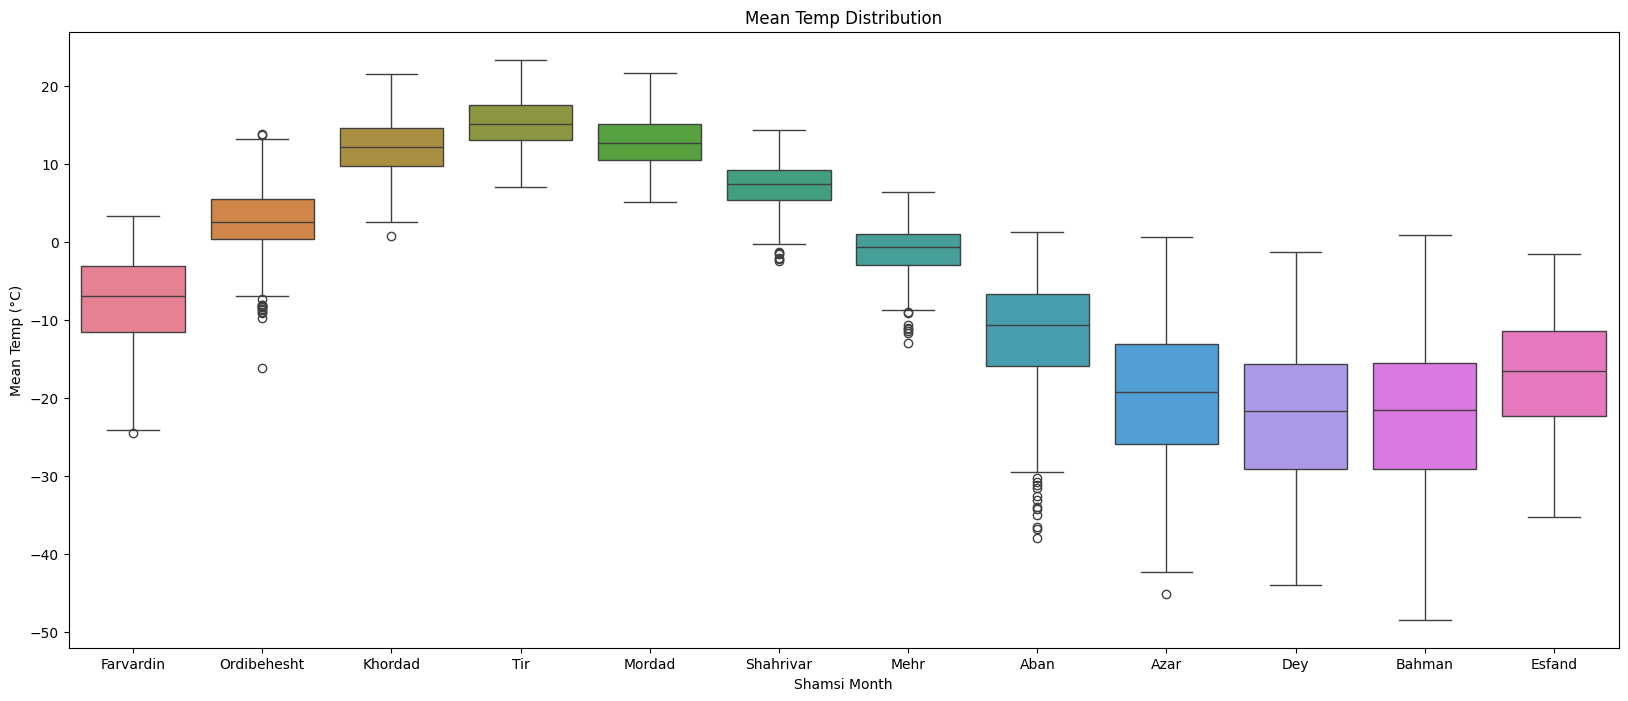

In [77]:
plt.figure(figsize=(20, 8))

sns.boxplot(
    data=df.sort_values(by='month_num'),
    x='shamsi_month',
    y='mean_temp',
    hue='shamsi_month',
    legend=False
)

plt.title('Mean Temp Distribution')

plt.xlabel('Shamsi Month')
plt.ylabel('Mean Temp (°C)')

plt.savefig('../src/img/mean_temp_dis.png', dpi=300, bbox_inches='tight')
plt.show()

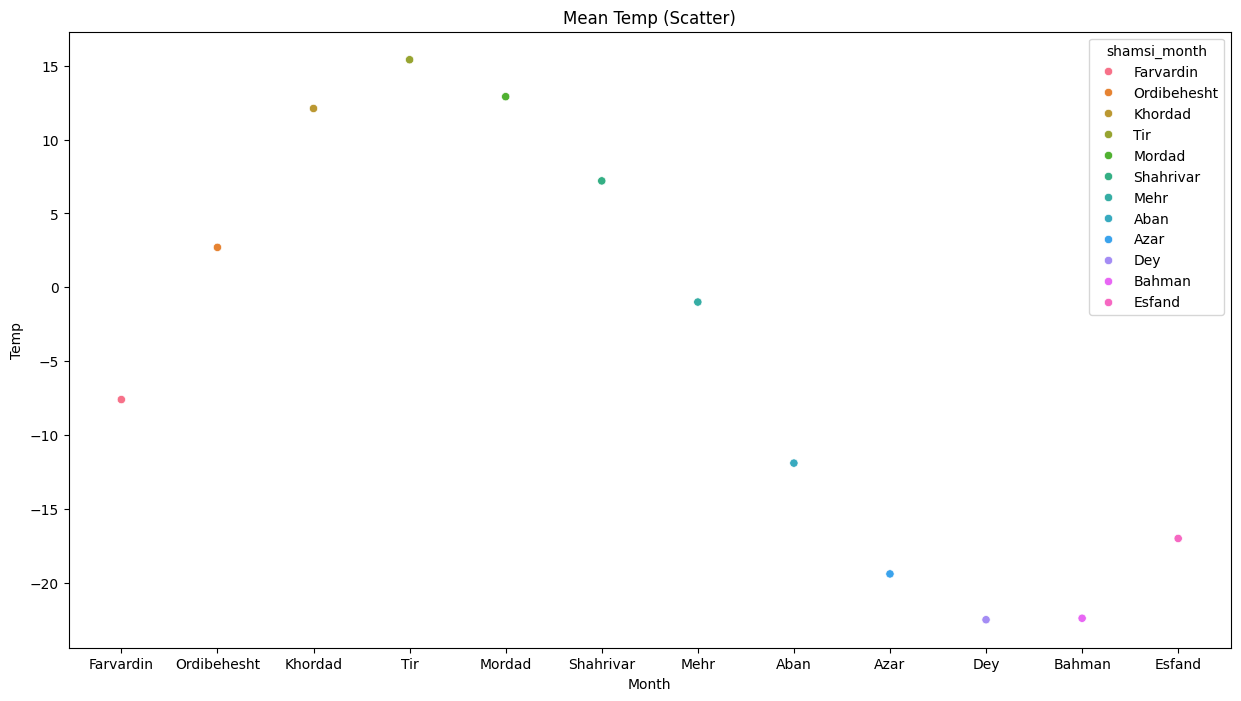

In [78]:
plt.figure(figsize=(15, 8))

sns.scatterplot(
    data=MonthMean,
    x='shamsi_month',
    y='mean_temp',
    hue='shamsi_month'
)

plt.title("Mean Temp (Scatter)")
plt.xlabel("Month")
plt.ylabel("Temp")

plt.savefig("../src/img/mean_temp_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

In [79]:
hottest_idx = df['max_temp'].idxmax()
hottest_day = df.loc[hottest_idx]

print(f"🔥 Hottest Day Date: {hottest_day['shamsi']}")
print(f"🌡️ Temperture: {hottest_day['max_temp']}")

🔥 Hottest Day Date: 1398-04-19
🌡️ Temperture: 29.2


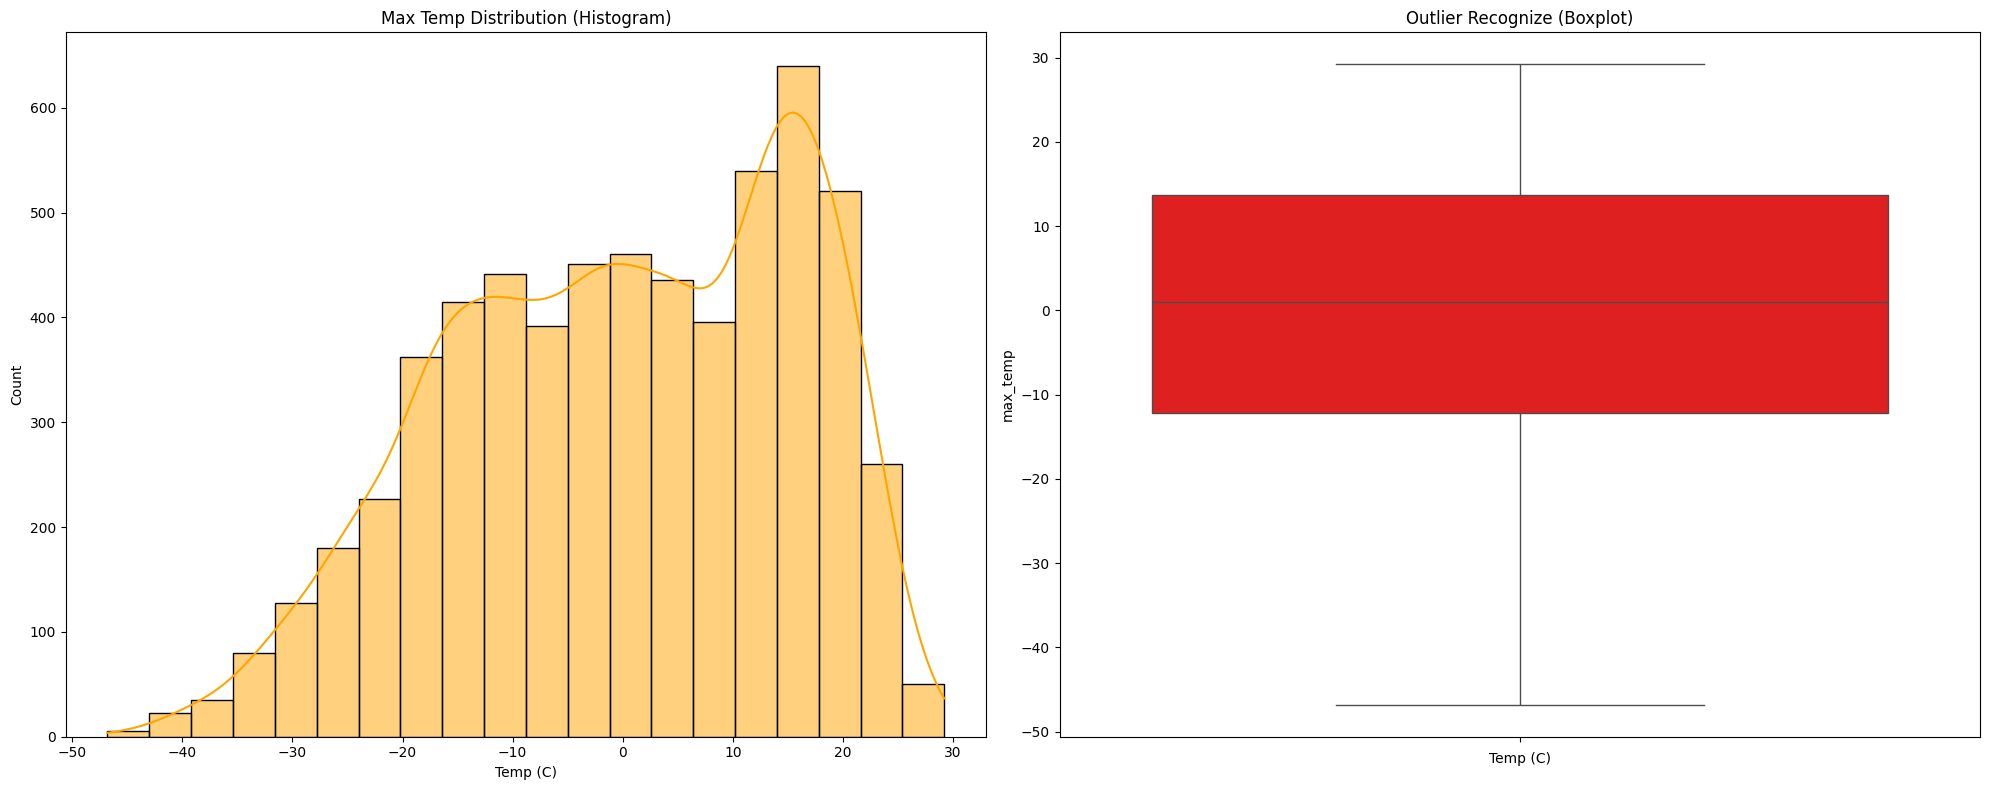

In [80]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)

sns.histplot(df['max_temp'], kde=True, color='orange', bins=20)
plt.title(f"Max Temp Distribution (Histogram)")
plt.xlabel('Temp (C)')


plt.subplot(1, 2, 2)
sns.boxplot(y=df['max_temp'], color='red')
plt.title('Outlier Recognize (Boxplot)')
plt.xlabel('Temp (C)')

plt.tight_layout()

plt.savefig('../src/img/Temp_Analyze.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
heatmap_data = df.pivot_table(index='shamsi_month', columns='day_num_of_month', values='mean_temp')

months_orders = [
    'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar',
    'Mehr', 'Aban', 'Azar', 'Dey', 'Bahman', 'Esfand'
]

existing_month = [m for m in months_orders if m in heatmap_data.index]
heatmap_data = heatmap_data.reindex(existing_month)

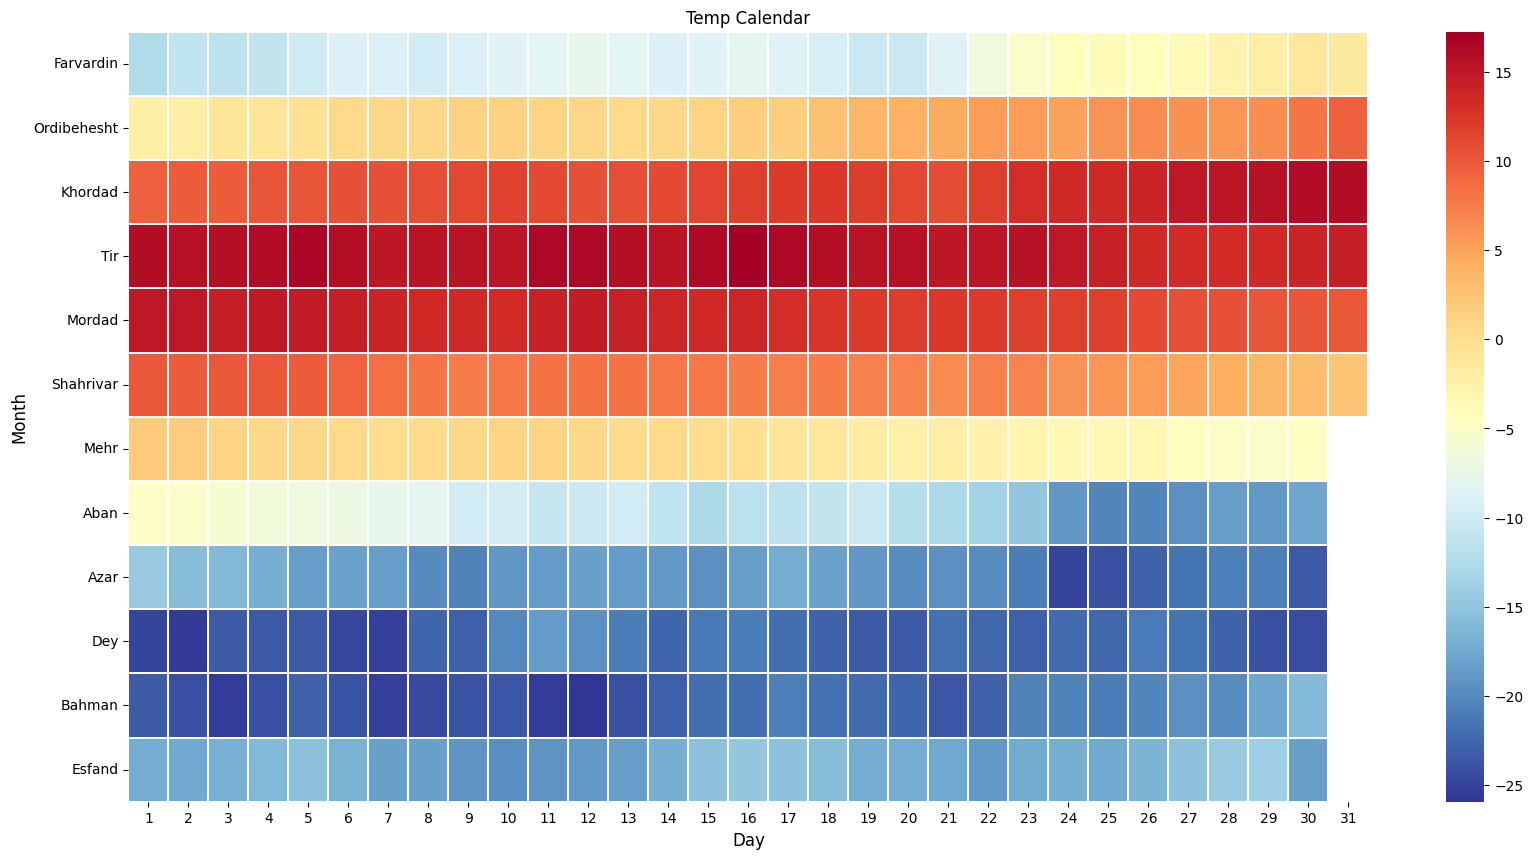

In [82]:
plt.figure(figsize=(20, 10))

sns.heatmap(
    data=heatmap_data,
    cmap='RdYlBu_r',
    linewidths=0.1,
    linecolor='white'
)

plt.title("Temp Calendar")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Month", fontsize=12)

plt.savefig("../src/img/Temp_Calender.png", dpi=300, bbox_inches='tight')
plt.show()